<a href="https://colab.research.google.com/github/Aadit2507/JOURNEY-GenAI/blob/main/FineTunning_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
#definig the device

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
#Data into train adn cal
BATCH_SIZE = 256
data_tranform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root ='./data', train =True , transform= data_tranform , download=True)
train_loader = DataLoader(train_dataset , batch_size= BATCH_SIZE , shuffle=True)

In [ ]:
#Class that defines AutoEncoder

class AutoEncoder(nn.Module):
  def __init__(self, latent_dim = 64, hidden_dim = 256 ):
    super(AutoEncoder, self).__init__()

    #Encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU()
    )
    #Decoder
    self.decoder = nn.Sequential(
        nn.ReLU(),
        nn.Linear(latent_dim, hidden_dim),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid()
    )
  def forward(self, x):
    z = self.encoder(x)
    x_recon = self.decoder(z)
    return x_recon

In [ ]:
model = AutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr= 1e-3)

In [ ]:
epochs = 5

model.train()
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader:
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad()
    x_recon = model(x)
    loss = criterion(x_recon, x)
    loss.backward()
    optimizer.step()
    total_loss = total_loss + loss.item()
  avg_loss = total_loss / len(train_loader)
  print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}')

Epoch 1/5, Loss: 0.052691
Epoch 2/5, Loss: 0.019891
Epoch 3/5, Loss: 0.012858
Epoch 4/5, Loss: 0.010348
Epoch 5/5, Loss: 0.008817


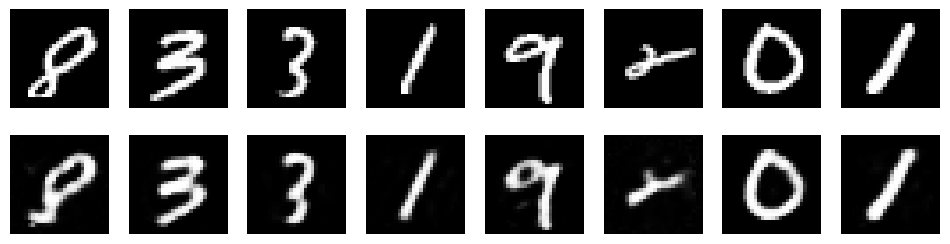

In [ ]:
#Evaluaton

model.eval()
with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 784).to(device)
    x_recon = model(x)
    n = 8
    plt.figure(figsize=(12, 3))
    for i in range(n):
      plt.subplot(2,n,i+1)
      plt.imshow(x[i].view(28, 28).cpu(), cmap='gray')
      plt.axis('off')

      plt.subplot(2,n,i+1+n)
      plt.imshow(x_recon[i].view(28, 28).cpu(), cmap='gray')
      plt.axis('off')

    plt.show()